In [25]:
import os
import urllib.request
if not os.path.exists('ahs_clean.zip'):
    urllib.request.urlretrieve("https://github.com/bquistorff/NABE_workbooks/raw/colab/ahs_clean.zip", 'ahs_clean.zip')

In [20]:
# PERF: If the Ridge or ENet regressions are slow, reduce n_alphas to 100
# PERF: If on limited hardware, reduce cv folds from 5 to 3
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import sklearn

from sklearn.linear_model import (
    LinearRegression, LassoCV, RidgeCV,
    lasso_path, enet_path
)
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.preprocessing import StandardScaler

random.seed(2718281)
np.random.seed(2718281)

### In this module you will learn:

1. How to work with real data to build a prediction model
2. We will build a hedonic model for house prices
3. In building this model we will explore different penalty methods including LASSO, Ridge, and Elastic-Net

### Housing Price Data

The following data is from the 2011 metropolitan sample of the American Housing Survey (Mullainathan Spiess 2017)

## Examining the Data

This isn't a huge dataset, but it's big enough where just looking at the spreadsheet isn't very informative. There are 212 covariates and 51,759 households.

In [3]:
with zipfile.ZipFile('ahs_clean.zip', 'r') as z:
    csv_name = z.namelist()[0]
    with z.open(csv_name) as f:
        Housing = pd.read_csv(f)
# Reads csv file into Python

print(Housing.iloc[:10, :10].to_string())
# Examine the first few rows and columns of our data

print(f'\nDataset dimensions: {Housing.shape}')
# Returns the dimension of the dataset


   LOGVALUE       LOT       UNITSF     CLIMB    DIRAC    NUMAIR  BUSPER  EXCLUS  HOWH   NUMCOLD
0  0.693147     900.0  2314.179989  2.011952  1.51928  1.730885     0.0     0.0   6.0  1.828194
1  0.693147   14520.0  2500.000000  2.011952  1.51928  1.730885     0.0     0.0  10.0  1.828194
2  0.693147   11000.0  7507.000000  2.011952  1.51928  1.000000     0.0     0.0   9.0  1.828194
3  1.609438   23760.0   830.000000  2.011952  1.51928  1.000000     0.0     0.0  10.0  1.828194
4  1.609438    3000.0  1100.000000  2.011952  1.51928  4.000000     0.0     0.0   7.0  1.828194
5  1.609438   44000.0  1000.000000  2.011952  1.51928  1.730885     0.0     0.0   6.0  1.828194
6  1.609438  220000.0  2000.000000  2.011952  1.51928  1.000000     1.0     0.0   8.0  1.828194
7  1.609438  220000.0  1800.000000  2.011952  1.51928  1.730885     0.0     0.0  10.0  1.828194
8  1.609438   33000.0  1200.000000  2.011952  1.51928  1.730885     1.0     0.0  10.0  1.828194
9  1.945910   44000.0  1957.000000  2.01

## Visualization and Descriptive Statistics

Instead of simply looking at the data table, let's start visualizing the distributions of some covariates. To get an idea of how we might do this consider some of the most important features of a house: Bedrooms, Full Bathrooms, Acreage, and Finished Area.

Let's plot the first two using bar plots and the later two with histograms. In addition we can look at the Five Number Summary for each of these covariates.

### What do we see?

Most houses have 2 Bedrooms and 3 Bathrooms. The distributions for acreage (LOT) and finished area (UNITSF) are non-negative and heavily skewed right. In this case it might be a good idea to take logarithms of both of these variables to reduce the impact of long tails in our analysis.

### Data Transformation

Let's transform and re-examine the distribution.

Prompt: `UNITSF` and `LOT` appear to be log-normally distributed. Create a new column the dataset that is the log transforms of each of those. The graph the histogram of those new variables.

In [4]:
Housing['LOGSQFT'] = np.log(Housing['UNITSF'])
Housing['LOGLOT'] = np.log(Housing['LOT'])

The transformation nearly eliminates the right skew. Let's go ahead and look at the relationships between these variables and the housing price.

### Visualization in High Dimensions

Even when we don't have a huge sample, it can be helpful to use subsamples to visualize the data. To see this, let's randomly select half of the observations to plot.


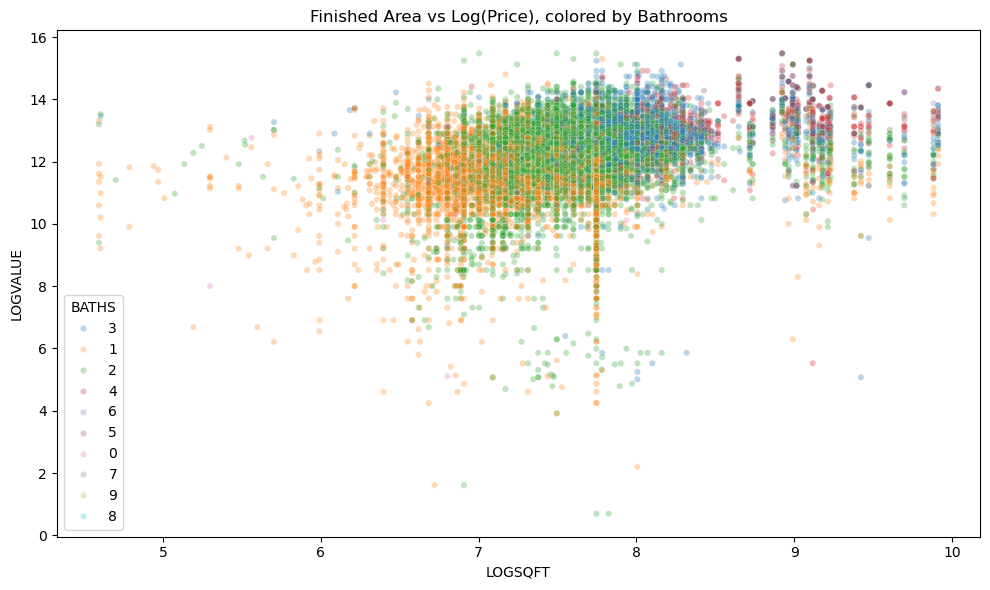

In [5]:
subset = Housing.sample(frac=0.5, random_state=2718281)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=subset, x='LOGSQFT', y='LOGVALUE',
                hue=subset['BATHS'].astype(str), alpha=0.3, s=20,
                legend='brief')
# Plotting relationship between Finished Area and log(price)
# Color based on number of full bathrooms
plt.title('Finished Area vs Log(Price), colored by Bathrooms')
plt.tight_layout()
plt.show()


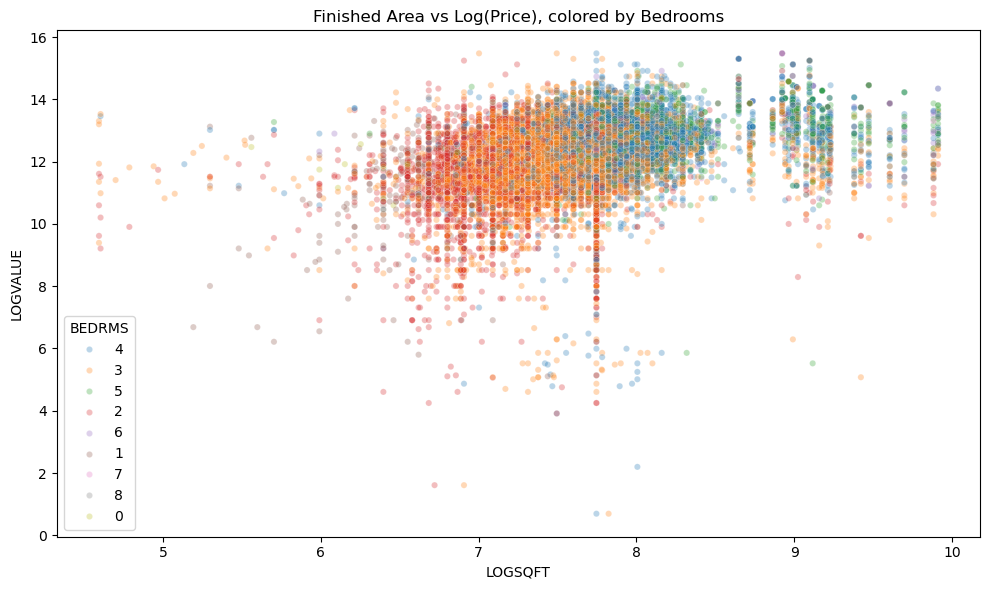

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=subset, x='LOGSQFT', y='LOGVALUE',
                hue=subset['BEDRMS'].astype(str), alpha=0.3, s=20,
                legend='brief')
# Plotting relationship between Finished Area and log(price)
# Color based on number of bedrooms
plt.title('Finished Area vs Log(Price), colored by Bedrooms')
plt.tight_layout()
plt.show()


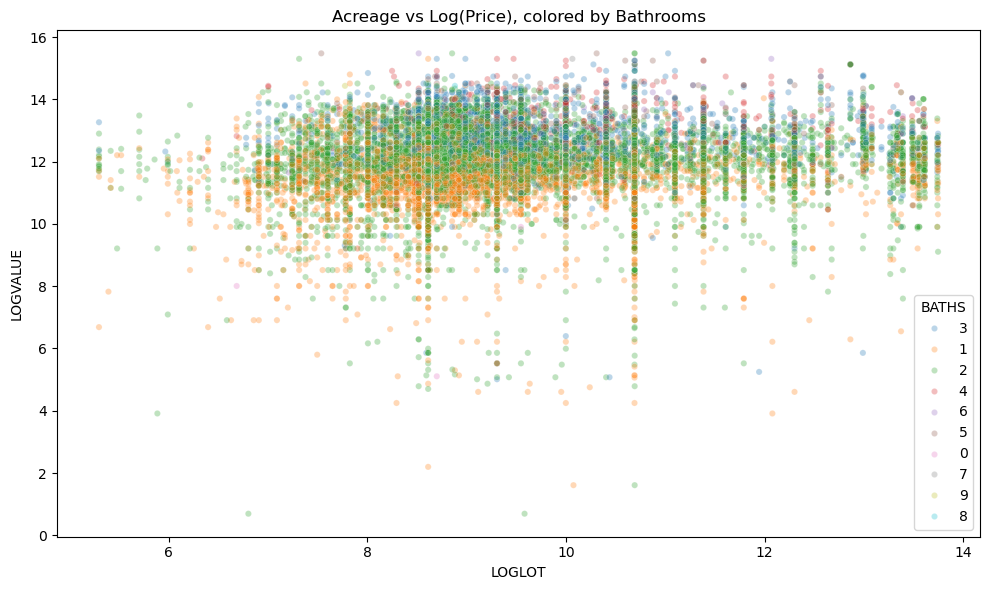

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=subset, x='LOGLOT', y='LOGVALUE',
                hue=subset['BATHS'].astype(str), alpha=0.3, s=20,
                legend='brief')
# Plotting relationship between Acreage and log(price)
# Color based on number of full bathrooms
plt.title('Acreage vs Log(Price), colored by Bathrooms')
plt.tight_layout()
plt.show()


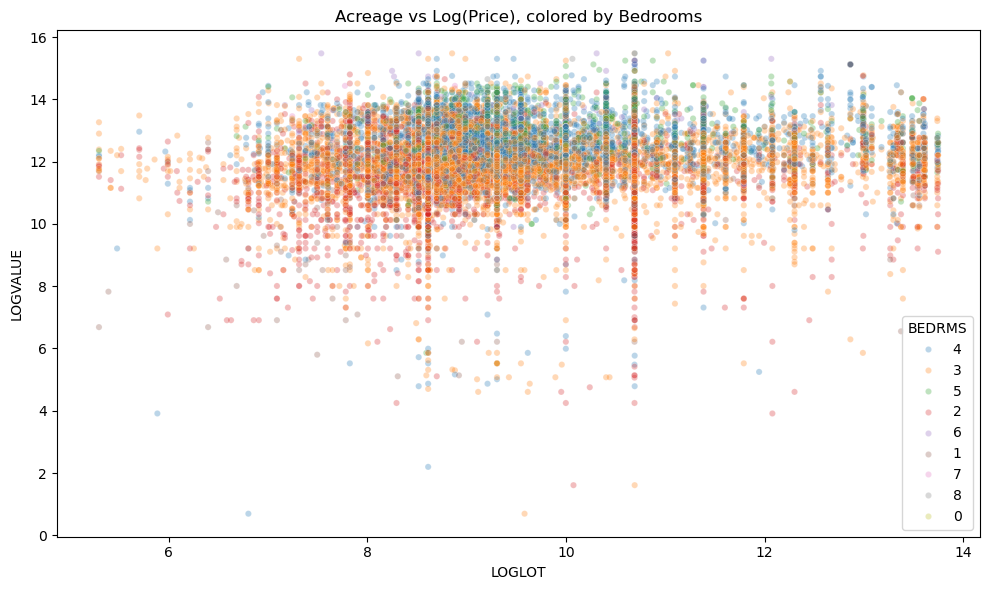

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=subset, x='LOGLOT', y='LOGVALUE',
                hue=subset['BEDRMS'].astype(str), alpha=0.3, s=20,
                legend='brief')
# Plotting relationship between Acreage and log(price)
# Color based on number of bedrooms
plt.title('Acreage vs Log(Price), colored by Bedrooms')
plt.tight_layout()
plt.show()


## What do we see?

We observe what we expect, houses with larger finished areas have more bedrooms and bathrooms. The results are much less clear between acreage and bathrooms and bedrooms which is intuitive as well.

It looks like there is a positive correlation between each of these covariates with price, but it is difficult to tease out relationships solely based on bivariate plots. Let's start running some regressions.

## Validation Set

First let's separate 10% of our sample as a validation set as before.

In [9]:
train_test, validation = train_test_split(Housing, test_size=0.1, random_state=2718281)

## Our First Regression

The first model we are running is $\log(value) = \beta_0 + \beta_1 \log(lot) + \beta_2 \log(sqft) + \beta_3 \text{bedrooms} + \beta_4 \text{bathrooms} + \varepsilon$

Once again we are going to evaluate the performance of this model based on cross-validation. Here we use scikit-learn's `cross_validate` function, which is the Python equivalent of caret's `train` with `trainControl(method="cv")`.

## First Steps with scikit-learn

The `cross_validate` function is a flexible way to evaluate models with various scoring metrics. We specify `cv=5` for 5-fold cross-validation.

In [10]:
train1 = train_test[['LOGVALUE', 'LOGLOT', 'LOGSQFT', 'BEDRMS', 'BATHS']]

X_train1 = train1.drop(columns=['LOGVALUE']).values
y_train1 = train1['LOGVALUE'].values

cv_results1 = cross_validate(
    LinearRegression(), X_train1, y_train1, cv=5,
    # 5-fold cross-validation
    scoring=['neg_root_mean_squared_error', 'r2', 'neg_mean_absolute_error']
)

rmse1 = -cv_results1['test_neg_root_mean_squared_error'].mean()
r2_1  =  cv_results1['test_r2'].mean()
mae1  = -cv_results1['test_neg_mean_absolute_error'].mean()

print(f"Linear Regression")
print(f"Samples: {len(y_train1)}, Predictors: {X_train1.shape[1]}")
print(f"Resampling: Cross-Validated (5 fold)")
print(f"\nResampling results:")
print(f"  RMSE       Rsquared  MAE")
print(f"  {rmse1:.7f}  {r2_1:.6f}  {mae1:.7f}")


Linear Regression
Samples: 46583, Predictors: 4
Resampling: Cross-Validated (5 fold)

Resampling results:
  RMSE       Rsquared  MAE
  0.8995691  0.192031  0.6070140


## First Regression Results

The results aren't great here, but we also are only taking into account a few of the covariates. Let's add in some of the location and house attributes.

## Building Richer Models

We can directly add the variables by their names by adding the columns to the training data.

In [11]:
extra_cols2 = ['REGION', 'METRO', 'KITCHEN', 'DISH', 'WASH', 'DRY', 'COOK',
               'DENS', 'DINING', 'FAMRM', 'HALFB', 'LIVING', 'OTHFN',
               'RECRM', 'PORCH', 'SINK', 'LAUNDY', 'FLOORS', 'CONDO',
               'ROOMS', 'PLUMB', 'NOWIRE', 'AGE']

train2 = pd.concat([train1, train_test[extra_cols2]], axis=1)

X_train2 = train2.drop(columns=['LOGVALUE']).values
y_train2 = train2['LOGVALUE'].values

cv_results2 = cross_validate(
    LinearRegression(), X_train2, y_train2, cv=5,
    scoring=['neg_root_mean_squared_error', 'r2', 'neg_mean_absolute_error']
)

rmse2 = -cv_results2['test_neg_root_mean_squared_error'].mean()
r2_2  =  cv_results2['test_r2'].mean()
mae2  = -cv_results2['test_neg_mean_absolute_error'].mean()

print(f"Linear Regression")
print(f"Samples: {len(y_train2)}, Predictors: {X_train2.shape[1]}")
print(f"Resampling: Cross-Validated (5 fold)")
print(f"\nResampling results:")
print(f"  RMSE       Rsquared   MAE")
print(f"  {rmse2:.7f}  {r2_2:.7f}  {mae2:.7f}")


Linear Regression
Samples: 46583, Predictors: 27
Resampling: Cross-Validated (5 fold)

Resampling results:
  RMSE       Rsquared   MAE
  0.8297487  0.3126155  0.5508645


The RMSE, MAE, and R-squared improve a bit here. We still have a lot of covariates we can consider though.

Let's add a few more features to see if we can get better results.

## Tricks to Select Data

Another way to select covariates in a DataFrame is with `.filter(regex=...)`. Here we are selecting all the covariates that have names beginning with "Roach", "Rats", "Water", "Cellar", "Num", and "Freeze".

In [12]:
extra_cols3 = pd.concat([
    train_test.filter(regex='^Roach'),
    train_test.filter(regex='^Rats'),
    train_test.filter(regex='^Water'),
    train_test.filter(regex='^Cellar'),
    train_test.filter(regex='^Num'),
    train_test.filter(regex='^Freeze'),
], axis=1)

train3 = pd.concat([train2, extra_cols3], axis=1)

X_train3 = train3.drop(columns=['LOGVALUE']).values
y_train3 = train3['LOGVALUE'].values

cv_results3 = cross_validate(
    LinearRegression(), X_train3, y_train3, cv=5,
    scoring=['neg_root_mean_squared_error', 'r2', 'neg_mean_absolute_error']
)

rmse3 = -cv_results3['test_neg_root_mean_squared_error'].mean()
r2_3  =  cv_results3['test_r2'].mean()
mae3  = -cv_results3['test_neg_mean_absolute_error'].mean()

print(f"Linear Regression")
print(f"Samples: {len(y_train3)}, Predictors: {X_train3.shape[1]}")
print(f"Resampling: Cross-Validated (5 fold)")
print(f"\nResampling results:")
print(f"  RMSE       Rsquared   MAE")
print(f"  {rmse3:.7f}  {r2_3:.7f}  {mae3:.7f}")


Linear Regression
Samples: 46583, Predictors: 27
Resampling: Cross-Validated (5 fold)

Resampling results:
  RMSE       Rsquared   MAE
  0.8297487  0.3126155  0.5508645


This model has ~60 predictors. This isn't huge on its own, but you could imagine by adding interactions and power terms the number of predictors would increase very fast.

## Shrinkage in Python

Once we have included all the covariates that we believe may be related to the model, we may want to apply a penalty term to improve out-of-sample performance. Python makes this very easy for all generalized linear models with the `scikit-learn` library.

We first standardize the features since regularization is sensitive to predictor scale.



In [13]:
y = train3['LOGVALUE'].values
X = train3.drop(columns=['LOGVALUE']).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## LASSO
Let's go ahead and run a LASSO regression on the last model we looked at.

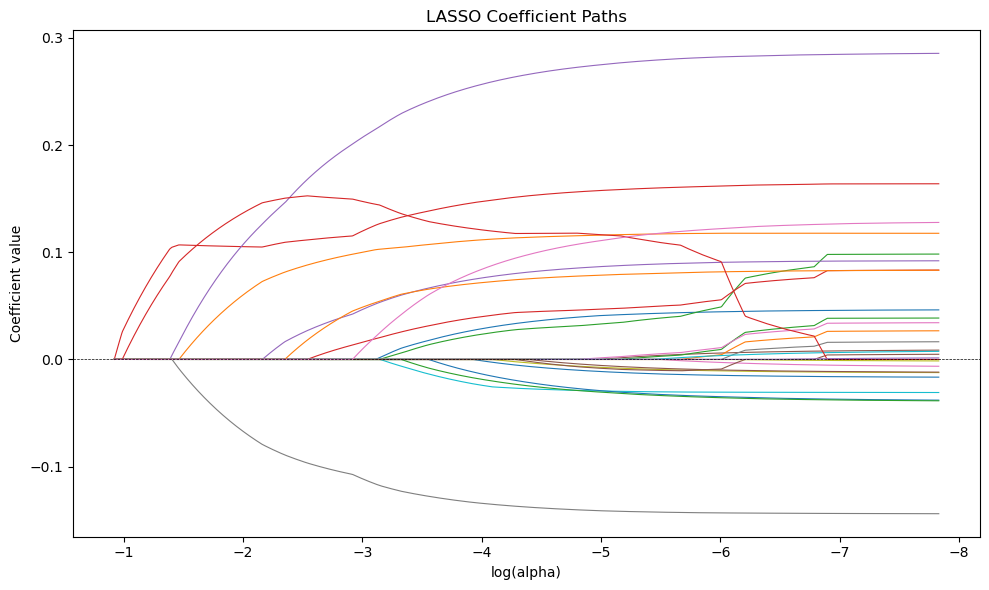

LassoCV(cv=5, max_iter=10000, n_alphas=1000, random_state=2718281)

In [14]:
# l1_ratio=1 corresponds to LASSO (alpha=1 in R's glmnet)

# --- Coefficient path ---
alphas_lasso, coefs_lasso, _ = lasso_path(X_scaled, y, n_alphas=1000)
# This gives the value of estimated coefficients across the regularization path

plt.figure(figsize=(10, 6))
for i in range(coefs_lasso.shape[0]):
    plt.plot(np.log(alphas_lasso), coefs_lasso[i], lw=0.8)
plt.xlabel('log(alpha)')
plt.ylabel('Coefficient value')
plt.title('LASSO Coefficient Paths')
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.gca().invert_xaxis()  # high regularization on left
plt.tight_layout()
plt.show()

# --- Cross-validate to find optimal lambda ---
cv_lasso = LassoCV(cv=5, n_alphas=1000, random_state=2718281, max_iter=10000)
cv_lasso.fit(X_scaled, y)
# This automatically cross-validates and optimizes over a grid of penalty weights



We observe quite a few coefficients go to zero for large values of alpha (high regularization), but many of them are just shrinking slowly to zero.

The same function works with other shrinkage penalties like Ridge and Elastic-Net.

## Ridge Regression

c:\Users\bquis\anaconda3\envs\Colab\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\bquis\anaconda3\envs\Colab\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3420814.9712726604, tolerance: 684.1634390318536
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\bquis\anaconda3\envs\Colab\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\bquis\anaconda3\envs\Colab\Lib\site-packages\sklearn\linear_model\_coor

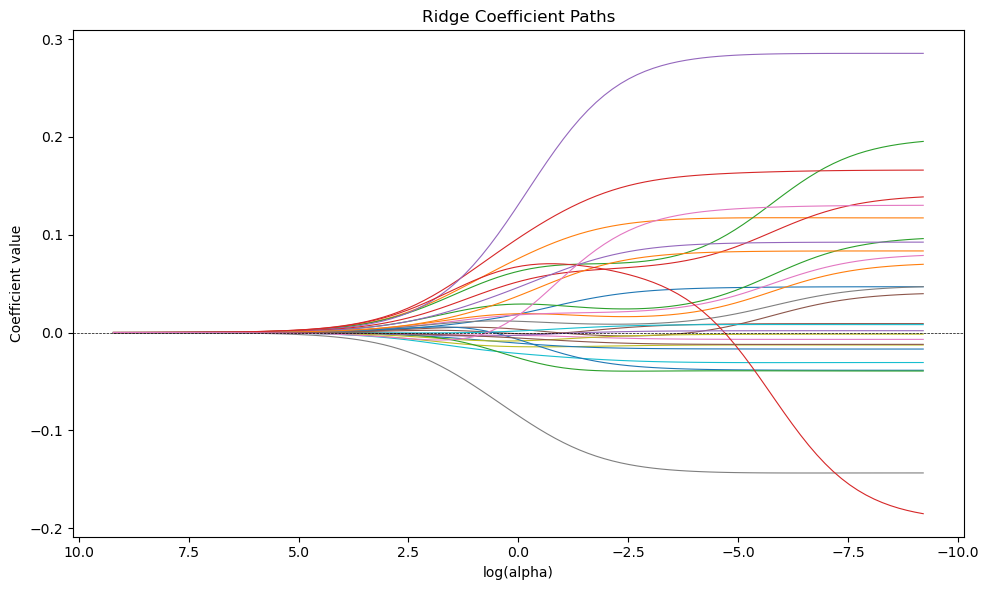

RidgeCV(alphas=array([1.00000000e-04, 1.20450354e-04, 1.45082878e-04, 1.74752840e-04,
       2.10490414e-04, 2.53536449e-04, 3.05385551e-04, 3.67837977e-04,
       4.43062146e-04, 5.33669923e-04, 6.42807312e-04, 7.74263683e-04,
       9.32603347e-04, 1.12332403e-03, 1.35304777e-03, 1.62975083e-03,
       1.96304065e-03, 2.36448941e-03, 2.84803587e-03, 3.43046929e-03,
       4.13201240e-03, 4.97702356e-0...
       1.38488637e+02, 1.66810054e+02, 2.00923300e+02, 2.42012826e+02,
       2.91505306e+02, 3.51119173e+02, 4.22924287e+02, 5.09413801e+02,
       6.13590727e+02, 7.39072203e+02, 8.90215085e+02, 1.07226722e+03,
       1.29154967e+03, 1.55567614e+03, 1.87381742e+03, 2.25701972e+03,
       2.71858824e+03, 3.27454916e+03, 3.94420606e+03, 4.75081016e+03,
       5.72236766e+03, 6.89261210e+03, 8.30217568e+03, 1.00000000e+04]),
        cv=5, scoring='neg_mean_squared_error')

In [15]:
# l1_ratio=0 corresponds to Ridge

# --- Coefficient path ---
n_alphas = 100
alphas_to_try = np.logspace(-4, 4, n_alphas)
# enet_path cannot auto-generate a grid when l1_ratio=0
alphas_ridge, coefs_ridge, _ = enet_path(X_scaled, y, l1_ratio=0, alphas=alphas_to_try)

plt.figure(figsize=(10, 6))
for i in range(coefs_ridge.shape[0]):
    plt.plot(np.log(alphas_ridge), coefs_ridge[i], lw=0.8)
plt.xlabel('log(alpha)')
plt.ylabel('Coefficient value')
plt.title('Ridge Coefficient Paths')
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

# --- Cross-validate to find optimal lambda ---
cv_ridge = RidgeCV(cv=5, scoring='neg_mean_squared_error', alphas=alphas_to_try)
cv_ridge.fit(X_scaled, y)


The coefficient paths are distinctly different for the LASSO and Ridge regressions. The Ridge penalty shrinks all the coefficients gradually to zero, while the LASSO sets them to zero at different rates and is much sharper.

## OLS vs Shrinkage

Comparing the results between OLS, LASSO, Ridge

In [16]:
ols_rmse    = rmse3

lasso_rmse  = np.sqrt(cv_lasso.mse_path_.mean(axis=1).min())
lasso_lambda = cv_lasso.alpha_

ridge_rmse  = np.sqrt(-cv_ridge.best_score_)
ridge_lambda = cv_ridge.alpha_

print(f"OLS RMSE:   {ols_rmse:.7f}")
print(f"Lasso RMSE: {lasso_rmse:.7f}, corresponding to Lambda: {lasso_lambda:.9f}")
print(f"Ridge RMSE: {ridge_rmse:.7f}, corresponding to Lambda: {ridge_lambda:.7f}")


OLS RMSE:   0.8297487
Lasso RMSE: 0.8299383, corresponding to Lambda: 0.000472680
Ridge RMSE: 0.8298544, corresponding to Lambda: 8.4975344


OLS is holding its own with the competing models on this metric.

## Validation Results

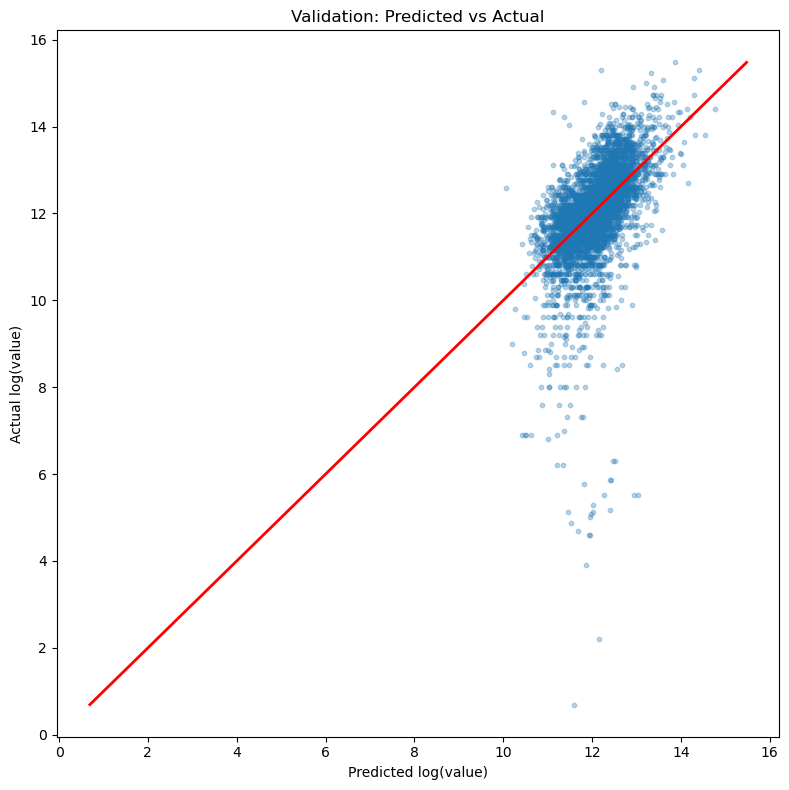

In [17]:
# Select the same feature columns used in train3
feature_cols = train3.drop(columns=['LOGVALUE']).columns

X_val = validation[feature_cols].values
X_val_scaled = scaler.transform(X_val)
y_val = validation['LOGVALUE'].values

yhat = cv_ridge.predict(X_val_scaled)

plt.figure(figsize=(8, 8))
plt.scatter(yhat, y_val, alpha=0.3, s=10)
lims = [min(yhat.min(), y_val.min()), max(yhat.max(), y_val.max())]
plt.plot(lims, lims, 'r-', lw=2)  # 45-degree reference line (perfect prediction)
plt.xlabel('Predicted log(value)')
plt.ylabel('Actual log(value)')
plt.title('Validation: Predicted vs Actual')
plt.tight_layout()
plt.show()


Not too bad! A perfect prediction would have all the points falling on the red line, but we are capturing a lot of the variation in the data.

## Exercise: Module 2

We have seen how to run a linear regression in Python and use it to predict housing prices. In the course material we examined the role of shrinkage in alleviating instability of OLS when the number of parameters is large relative to the sample size. To see how this might help in practice let's consider a random subsample of this data (10%)

1. Run OLS, LASSO, Ridge, and Elastic-Net (l1_ratio=0.5)
2. What shrinkage parameters get selected?
3. Which model does best in terms of out-of-sample performance?
4. Do you notice a significant performance increase between the shrinkage estimators and OLS?

In [18]:
subset = Housing.sample(frac=0.1, random_state=2718281)

sub_train, sub_val = train_test_split(subset, test_size=0.1, random_state=2718281)

y_sub = subset['LOGVALUE'].values
X_sub = subset.drop(columns=['LOGVALUE']).values

scaler_sub = StandardScaler()
X_sub_scaled = scaler_sub.fit_transform(X_sub)

cv_lasso_sub = LassoCV(cv=5, n_alphas=100, random_state=2718281, max_iter=10000)
cv_lasso_sub.fit(X_sub_scaled, y_sub)

cv_ridge_sub = RidgeCV(alphas=np.logspace(-4, 4, 100), cv=5,
                       scoring='neg_mean_squared_error')
cv_ridge_sub.fit(X_sub_scaled, y_sub)


lasso_rmse_sub = np.sqrt(cv_lasso_sub.mse_path_.mean(axis=1).min())
ridge_rmse_sub = np.sqrt(-cv_ridge_sub.best_score_)

print(f"Lasso RMSE: {lasso_rmse_sub:.7f}, corresponding to Lambda: {cv_lasso_sub.alpha_:.9f}")
print(f"Ridge RMSE: {ridge_rmse_sub:.7f}, corresponding to Lambda: {cv_ridge_sub.alpha_:.7f}")

Lasso RMSE: 0.8009056, corresponding to Lambda: 0.011510788
Ridge RMSE: 0.8077222, corresponding to Lambda: 1072.2672220


In [23]:
# Reproducibility info
import sys, matplotlib
print(f"Python:       {sys.version}")
print(f"NumPy:        {np.__version__}")
print(f"pandas:       {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"matplotlib:   {matplotlib.__version__}")
print(f"seaborn:      {sns.__version__}")


Python:       3.12.12 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 20:05:38) [MSC v.1929 64 bit (AMD64)]
NumPy:        1.26.4
pandas:       2.2.2
scikit-learn: 1.6.1
matplotlib:   3.10.0
seaborn:      0.13.2
